In [1]:
# ---- Standard-library imports ----
import pathlib  # resolve the downloaded dataset path
import random
import subprocess
import sys

# ---- Dataset loader (installed automatically on first use if missing) ----
try:
    import kagglehub
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True
    )
    import kagglehub

# ---- Data handling & plotting ----
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# ---- scikit-learn: models, preprocessing, selection & evaluation ----
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeClassifier

# ---- Reproducible project seed ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Shared style so every chart looks the same (bold labels, 150 dpi).
plt.rcParams.update(
    {
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "figure.dpi": 150,
    }
)

# Same 3 colors used in all the plots below.
PALETTE = ["#EA2027", "#006266", "#1B1464"]

In [3]:
# 1. Load the Kaggle dataset (kagglehub downloads it for us).
path = kagglehub.dataset_download("dnkumars/cybersecurity-intrusion-detection-dataset")
df = pd.read_csv(next(pathlib.Path(path).glob("*.csv")))
print(f"Shape: {df.shape}")
df.head()

Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [4]:
# 2. Quick look at the data - just summary stats.
print(df.describe(include="all").T.to_string())

# Also see how many missing values and duplicate rows there are.
print("\nMissing values per column:\n", df.isnull().sum().to_string())
print("\nDuplicate rows:", df.duplicated().sum())

                      count unique        top  freq        mean         std       min         25%         50%          75%          max
session_id             9537   9537  SID_00001     1         NaN         NaN       NaN         NaN         NaN          NaN          NaN
network_packet_size  9537.0    NaN        NaN   NaN  500.430639  198.379364      64.0       365.0       499.0        635.0       1285.0
protocol_type          9537      3        TCP  6624         NaN         NaN       NaN         NaN         NaN          NaN          NaN
login_attempts       9537.0    NaN        NaN   NaN    4.032086    1.963012       1.0         3.0         4.0          5.0         13.0
session_duration     9537.0    NaN        NaN   NaN  792.745312  786.560144       0.5  231.953006  556.277457  1105.380602  7190.392213
encryption_used        7571      2        AES  4706         NaN         NaN       NaN         NaN         NaN          NaN          NaN
ip_reputation_score  9537.0    NaN        NaN   

attack_detected
0    5273
1    4264
Name: count, dtype: int64


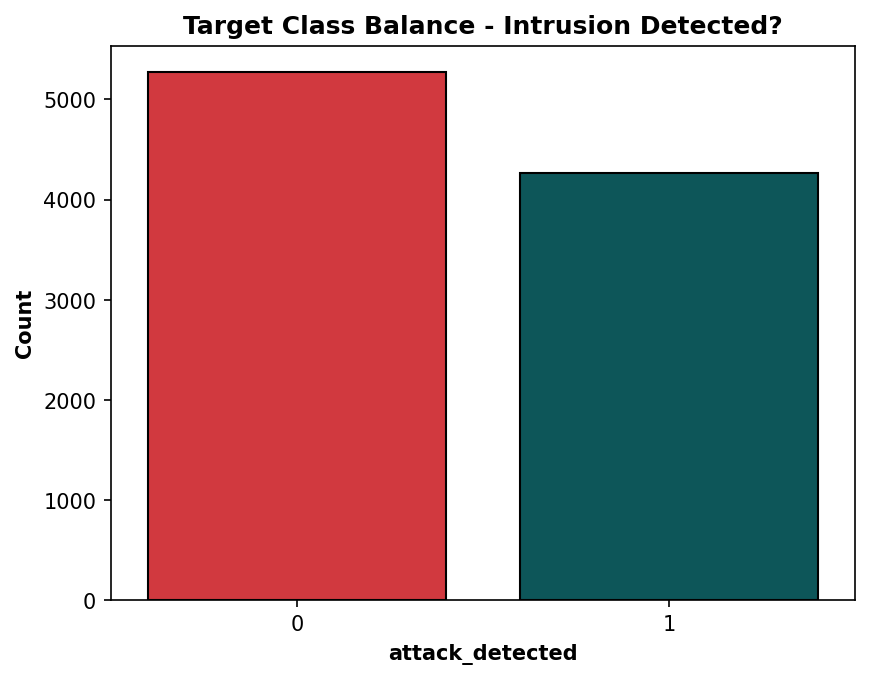

In [5]:
# 3. Check the target classes - is this balanced?
print(df["attack_detected"].value_counts().sort_index())

sns.countplot(
    data=df,
    x="attack_detected",
    hue="attack_detected",
    palette=PALETTE[:2],  # only 2 classes, so just 2 colors (avoids a warning)
    legend=False,
    edgecolor="black",
)
plt.title("Target Class Balance - Intrusion Detected?")
plt.xlabel("attack_detected")
plt.ylabel("Count")
plt.show()

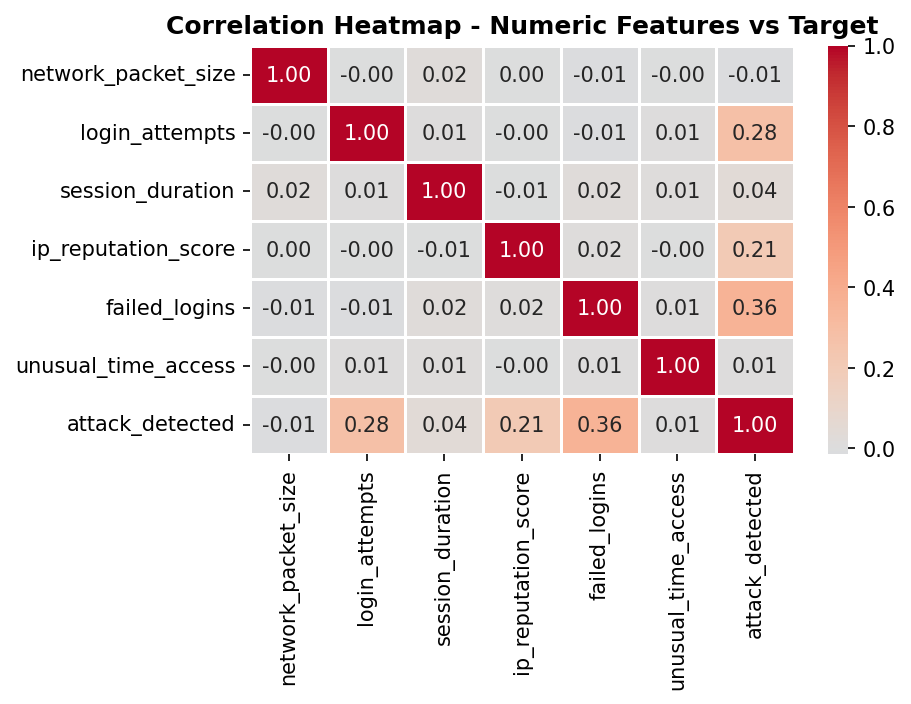

In [6]:
# EDA: correlations among the numeric features. Plain stats, nothing fitted, so no leak here.
numeric_cols = [
    "network_packet_size",
    "login_attempts",
    "session_duration",
    "ip_reputation_score",
    "failed_logins",
    "unusual_time_access",
]
plt.figure()
sns.heatmap(
    df[numeric_cols + ["attack_detected"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    center=0,
)
plt.title("Correlation Heatmap - Numeric Features vs Target")
plt.tight_layout()
plt.show()

In [7]:
# 4. Preprocessing helpers, plus a few per-row features that need no fitting.
def drop_identifier(dataframe, column):
    """Drop a column that is just an ID."""
    return dataframe.drop(columns=column)


def compute_categorical_modes(dataframe):
    """Most common value of each text column. Fit on TRAIN only."""
    return {
        col: dataframe[col].mode()[0]
        for col in dataframe.columns
        if dataframe[col].dtype == "object" or dataframe[col].dtype == "string"
    }


def impute_with_modes(dataframe, modes):
    """Fill missing category values with the stored modes."""
    for col, mode in modes.items():
        dataframe[col] = dataframe[col].fillna(mode)
    return dataframe


def one_hot_encode_columns(dataframe, columns):
    """One-hot encode the category columns."""
    return pd.get_dummies(dataframe, columns=columns, drop_first=True)


# These per-row features are just arithmetic - they can't leak anything.
df = drop_identifier(df, "session_id")  # session_id is just an ID, no signal
df["failed_login_ratio"] = (
    df["failed_logins"] / df["login_attempts"]
)  # share of attempts that fail
df["packet_x_duration"] = (
    df["network_packet_size"] * df["session_duration"]
)  # packet size x session length
df["login_rate"] = df["login_attempts"] / df["session_duration"]  # attempts per second

In [8]:
# 5. Leakage-safe order: split first, then fit every step (filling, imputing, scaling, RFE) on TRAIN only.
X = df.drop(columns="attack_detected")
y = df["attack_detected"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Raw split -> Train: {X_train.shape} | Test: {X_test.shape}")

# Fill protocol_type & browser_type using the modes from the train set.
mode_cols = ["protocol_type", "browser_type"]
categorical_modes = compute_categorical_modes(X_train)
categorical_modes = {col: categorical_modes[col] for col in mode_cols}
X_train = impute_with_modes(X_train, categorical_modes)
X_test = impute_with_modes(X_test, categorical_modes)

# encryption_used has ~20% blanks - fill them with KNN imputation (fit on train only).
enc_labels = sorted(X_train["encryption_used"].dropna().unique())  # e.g. ['AES', 'DES']
enc_encoder = {label: i for i, label in enumerate(enc_labels)}
enc_inverse = {i: label for label, i in enc_encoder.items()}

# 1) Turn AES/DES into numbers first (missing values just stay blank).
enc_train = X_train["encryption_used"].map(enc_encoder)
enc_test = X_test["encryption_used"].map(enc_encoder)

# 2) Scale the numeric features that define "neighbors" (train only).
neighbor_features = [
    "network_packet_size",
    "login_attempts",
    "session_duration",
    "ip_reputation_score",
    "failed_logins",
    "unusual_time_access",
]
neighbor_scaler = StandardScaler()
nb_train = pd.DataFrame(
    neighbor_scaler.fit_transform(X_train[neighbor_features]),
    columns=neighbor_features,
    index=X_train.index,
)
nb_test = pd.DataFrame(
    neighbor_scaler.transform(X_test[neighbor_features]),
    columns=neighbor_features,
    index=X_test.index,
)
train_block = pd.concat([nb_train, enc_train.to_frame("enc")], axis=1)
test_block = pd.concat([nb_test, enc_test.to_frame("enc")], axis=1)

# 3) Impute the blanks in the encrypted column.
enc_imputer = KNNImputer(n_neighbors=5)
imputed_train = pd.DataFrame(
    enc_imputer.fit_transform(train_block),
    columns=train_block.columns,
    index=train_block.index,
)
imputed_test = pd.DataFrame(
    enc_imputer.transform(test_block),
    columns=test_block.columns,
    index=test_block.index,
)

# 4) Round to the closest number and map back to AES/DES.
X_train["encryption_used"] = imputed_train["enc"].round().astype(int).map(enc_inverse)
X_test["encryption_used"] = imputed_test["enc"].round().astype(int).map(enc_inverse)
print(
    "encryption_used imputed - remaining NaN -> train: "
    f"{X_train['encryption_used'].isna().sum()}, test: {X_test['encryption_used'].isna().sum()}"
)

# One-hot encode, then force test to have exactly the same columns (missing -> 0).
categorical_cols = ["protocol_type", "encryption_used", "browser_type"]
X_train = one_hot_encode_columns(X_train, categorical_cols)
X_test = one_hot_encode_columns(X_test, categorical_cols)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Scale the numeric columns but leave the 0/1 time-access flag as is.
continuous_cols = [
    "network_packet_size",
    "login_attempts",
    "session_duration",
    "ip_reputation_score",
    "failed_logins",
    "failed_login_ratio",
    "packet_x_duration",
    "login_rate",
]
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

# RFE keeps the 8 most useful features for KNN.
selector = RFE(
    LogisticRegression(max_iter=1000, random_state=SEED), n_features_to_select=8
)
selector.fit(X_train, y_train)
rfe_kept = list(X_train.columns[selector.support_])
X_train = X_train.loc[:, selector.support_]
X_test = X_test.loc[:, selector.support_]
print(f"After RFE (top-8 features) -> Train: {X_train.shape} | Test: {X_test.shape}")
print("RFE kept:", rfe_kept)

Raw split -> Train: (7629, 12) | Test: (1908, 12)
encryption_used imputed - remaining NaN -> train: 0, test: 0
After RFE (top-8 features) -> Train: (7629, 8) | Test: (1908, 8)
RFE kept: ['login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'failed_login_ratio', 'encryption_used_DES', 'browser_type_Unknown']


In [9]:
# 6. A few helpers so I don't repeat the same code for every model.
def compute_metrics(y_true, y_pred):
    """Accuracy, precision, recall, F1."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1-Score": f1_score(y_true, y_pred, average="weighted"),
    }


def evaluate_classifier(name, model, X_train, y_train, X_test, y_test):
    """Fit, predict, print a one-liner, and hand back metrics + predictions."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = compute_metrics(y_test, y_pred)
    print(
        f"{name}: Accuracy={metrics['Accuracy']:.4f}  "
        f"Precision={metrics['Precision']:.4f}  "
        f"Recall={metrics['Recall']:.4f}  "
        f"F1={metrics['F1-Score']:.4f}"
    )
    return metrics, y_pred


def plot_confusion_matrix(axes, y_true, y_pred, title, classes):
    """Draw a labelled confusion-matrix heatmap."""
    sns.heatmap(
        confusion_matrix(y_true, y_pred),
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes,
        xticklabels=classes,
        yticklabels=classes,
        cbar=False,
    )
    axes.set_title(title)
    axes.set_xlabel("Predicted")
    axes.set_ylabel("Actual")


def plot_metric_bars(metrics_table, title="Model Performance Comparison"):
    """One bar chart for any metrics comparison table."""
    axes = metrics_table.plot(kind="bar", color=PALETTE, edgecolor="black", width=0.85)
    axes.set_title(title)
    axes.set_ylabel("Score")
    axes.set_xticklabels(axes.get_xticklabels(), rotation=0)
    axes.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [10]:
# 7. Train the 3 baseline models and score them on the held-out test set.
CLASSES = ["No attack", "Attack"]

models = {
    "DT": DecisionTreeClassifier(
        random_state=SEED,
        ccp_alpha=0.0,
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "LR": LogisticRegression(max_iter=1000, random_state=SEED),
}

results = {}
for name, model in models.items():
    metrics, _ = evaluate_classifier(name, model, X_train, y_train, X_test, y_test)
    results[name] = metrics

DT: Accuracy=0.8040  Precision=0.8042  Recall=0.8040  F1=0.8041
KNN: Accuracy=0.8475  Precision=0.8570  Recall=0.8475  F1=0.8446
LR: Accuracy=0.7526  Precision=0.7522  Recall=0.7526  F1=0.7510


In [11]:
# 8. GridSearchCV to tune each model; we print the best combo and a short top-5.
def grid_search(model, params, label):
    """5-fold grid search on accuracy; returns the best estimator."""
    gs = GridSearchCV(model, params, cv=5, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    top5 = (
        pd.DataFrame(gs.cv_results_)
        .sort_values("rank_test_score")
        .head(5)[["rank_test_score", "mean_test_score", "params"]]
    )
    print()
    print(f"=== {label} ===")
    print(f"Best CV accuracy = {gs.best_score_:.4f}  |  params = {gs.best_params_}")
    print(top5.to_string(index=False))
    return gs.best_estimator_


# The per-class report and confusion matrices below use these TUNED predictions.
tuned_preds = {}

tuned_dt = grid_search(
    DecisionTreeClassifier(random_state=SEED, ccp_alpha=0.0),
    {
        "max_depth": [3, 5, 7, 9],
        "min_samples_leaf": [1, 5, 10],
        "min_samples_split": [2, 5, 10],
        "criterion": ["gini", "entropy"],
        "class_weight": ["balanced", None],
        "ccp_alpha": [0.0, 0.001, 0.005, 0.01],
    },
    "Decision Tree",
)
metrics, y_pred = evaluate_classifier(
    "Tuned DT", tuned_dt, X_train, y_train, X_test, y_test
)
results["Tuned DT"] = metrics
tuned_preds["Tuned DT"] = y_pred

tuned_knn = grid_search(
    KNeighborsClassifier(n_neighbors=5),
    {
        "n_neighbors": [5, 7, 9, 11, 13],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"],
    },
    "KNN",
)
metrics, y_pred = evaluate_classifier(
    "Tuned KNN", tuned_knn, X_train, y_train, X_test, y_test
)
results["Tuned KNN"] = metrics
tuned_preds["Tuned KNN"] = y_pred

# LR is only tuned on C and class_weight; the penalty and solver stay as sklearn defaults.
tuned_lr = grid_search(
    LogisticRegression(max_iter=1000, random_state=SEED),
    {
        "C": [0.01, 0.1, 1, 10],
        "class_weight": ["balanced", None],
    },
    "Logistic Regression",
)
metrics, y_pred = evaluate_classifier(
    "Tuned LR", tuned_lr, X_train, y_train, X_test, y_test
)
results["Tuned LR"] = metrics
tuned_preds["Tuned LR"] = y_pred


=== Decision Tree ===
Best CV accuracy = 0.8972  |  params = {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
 rank_test_score  mean_test_score                                                                                                                              params
               1         0.897233  {'ccp_alpha': 0.001, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 10}
               1         0.897233  {'ccp_alpha': 0.001, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
               1         0.897233 {'ccp_alpha': 0.001, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 10}
               1         0.897233  {'ccp_alpha': 0.001, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_s

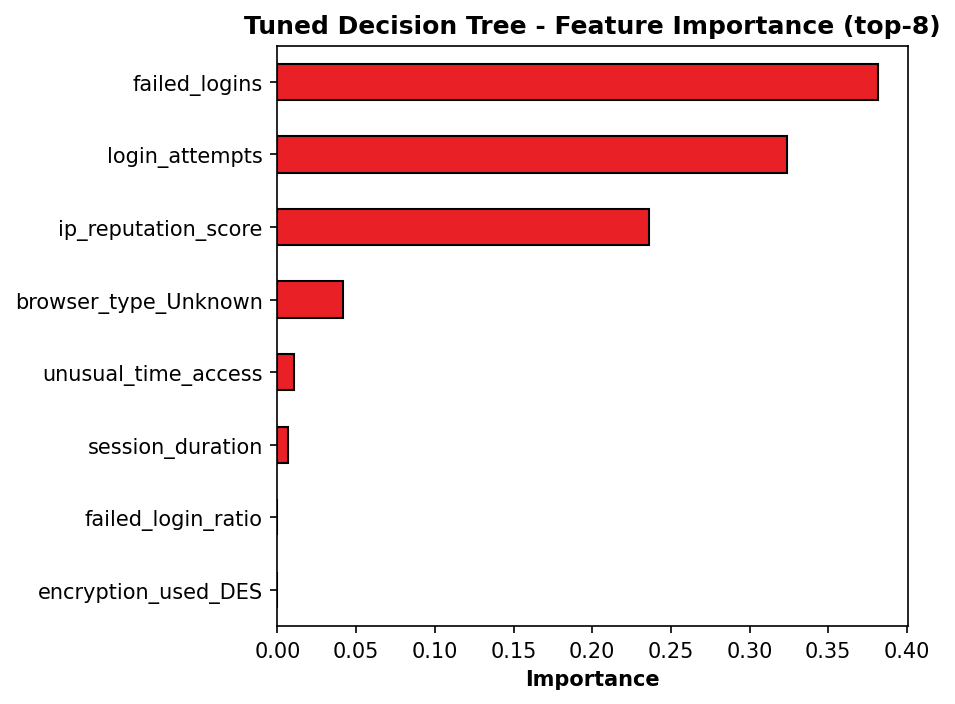

In [12]:
# Which of the 8 RFE features matter most in the tuned tree?
importance = pd.Series(
    tuned_dt.feature_importances_, index=X_train.columns
).sort_values()
importance.plot(kind="barh", color=PALETTE[0], edgecolor="black")
plt.title("Tuned Decision Tree - Feature Importance (top-8)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [13]:
# 9. Per-class report - mainly checking each model on the minority 'Attack' class.
for name, y_pred in tuned_preds.items():
    print(f"\n{'=' * 50}\n{name}\n{'=' * 50}")
    print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))


Tuned DT
              precision    recall  f1-score   support

   No attack     0.8294    1.0000    0.9067      1055
      Attack     1.0000    0.7456    0.8543       853

    accuracy                         0.8863      1908
   macro avg     0.9147    0.8728    0.8805      1908
weighted avg     0.9057    0.8863    0.8833      1908


Tuned KNN
              precision    recall  f1-score   support

   No attack     0.8115    0.9915    0.8925      1055
      Attack     0.9855    0.7151    0.8288       853

    accuracy                         0.8679      1908
   macro avg     0.8985    0.8533    0.8606      1908
weighted avg     0.8893    0.8679    0.8640      1908


Tuned LR
              precision    recall  f1-score   support

   No attack     0.7564    0.8152    0.7847      1055
      Attack     0.7471    0.6753    0.7094       853

    accuracy                         0.7526      1908
   macro avg     0.7517    0.7452    0.7470      1908
weighted avg     0.7522    0.7526    0.7510

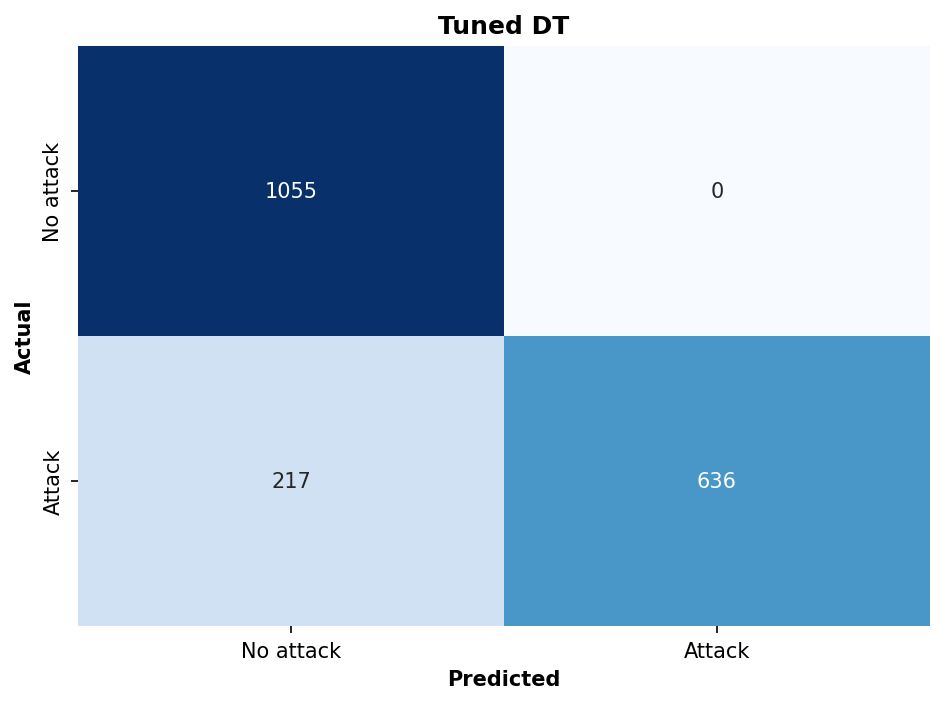

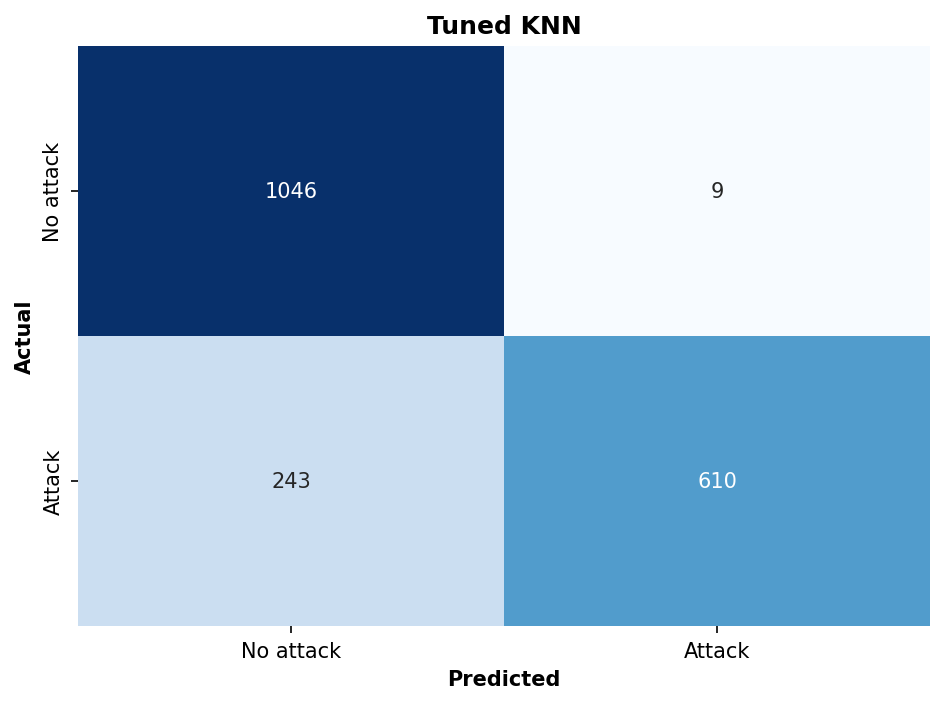

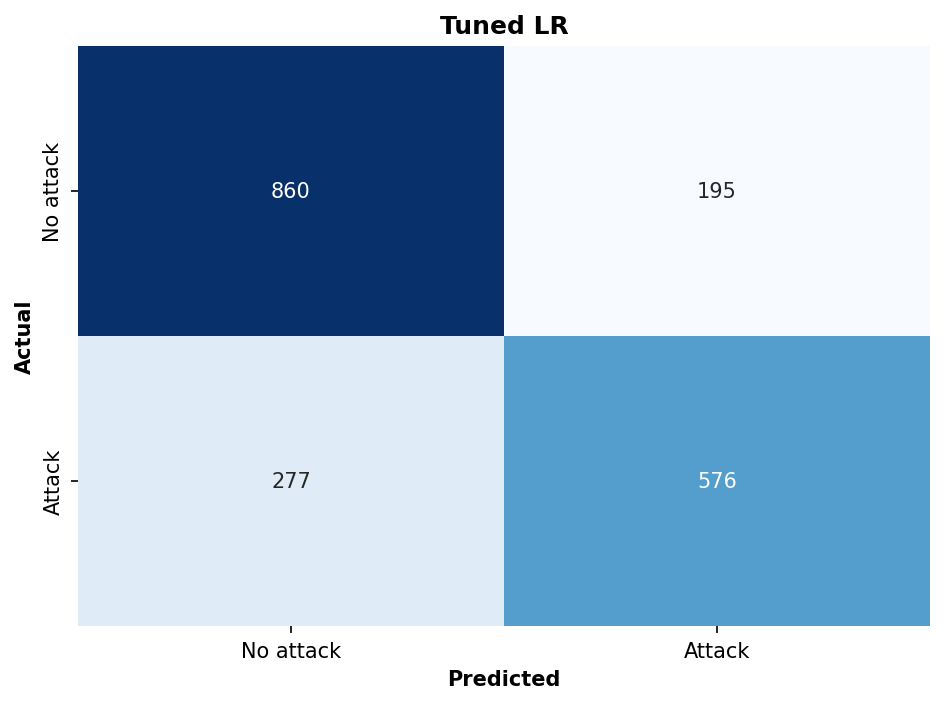

In [14]:
# 10. Confusion matrix for each tuned model.
for name, y_pred in tuned_preds.items():
    fig, ax = plt.subplots()
    plot_confusion_matrix(ax, y_test, y_pred, name, CLASSES)
    plt.tight_layout()
    plt.show()

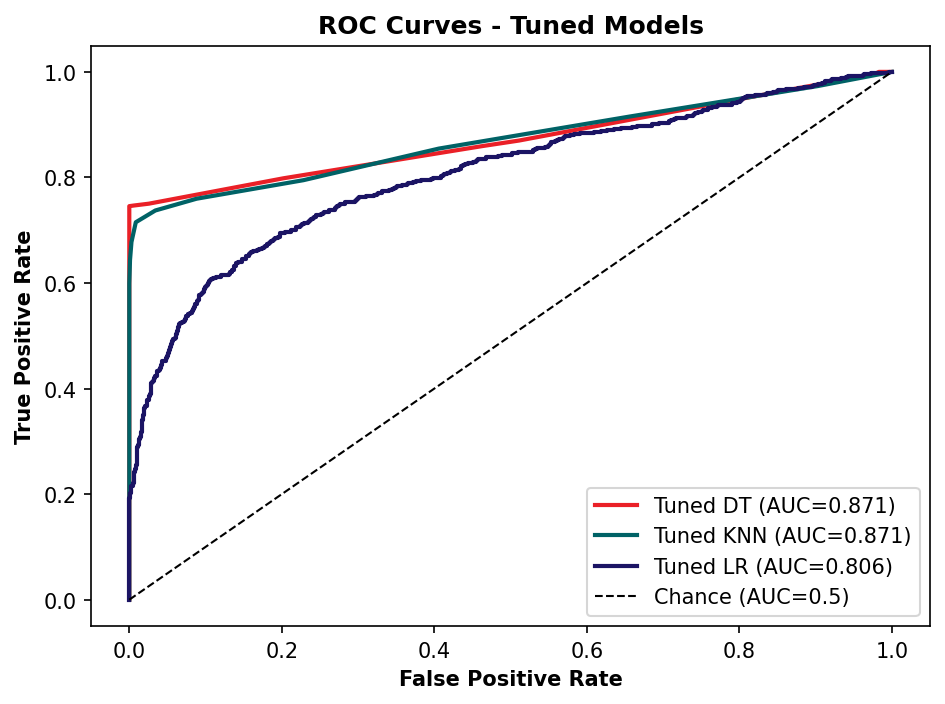

In [15]:
# 11. ROC curves for the 3 tuned models, on the held-out test set.

# Match each curve to its color in the shared palette.
roc_colors = {"Tuned DT": PALETTE[0], "Tuned KNN": PALETTE[1], "Tuned LR": PALETTE[2]}

fig, ax = plt.subplots()
for name, model in {
    "Tuned DT": tuned_dt,
    "Tuned KNN": tuned_knn,
    "Tuned LR": tuned_lr,
}.items():
    # Grab the 'Attack' (=1) column by label, not a hard-coded index.
    positive_col = int(np.flatnonzero(model.classes_ == 1)[0])
    proba = model.predict_proba(X_test)[:, positive_col]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2, color=roc_colors[name], label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Tuned Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

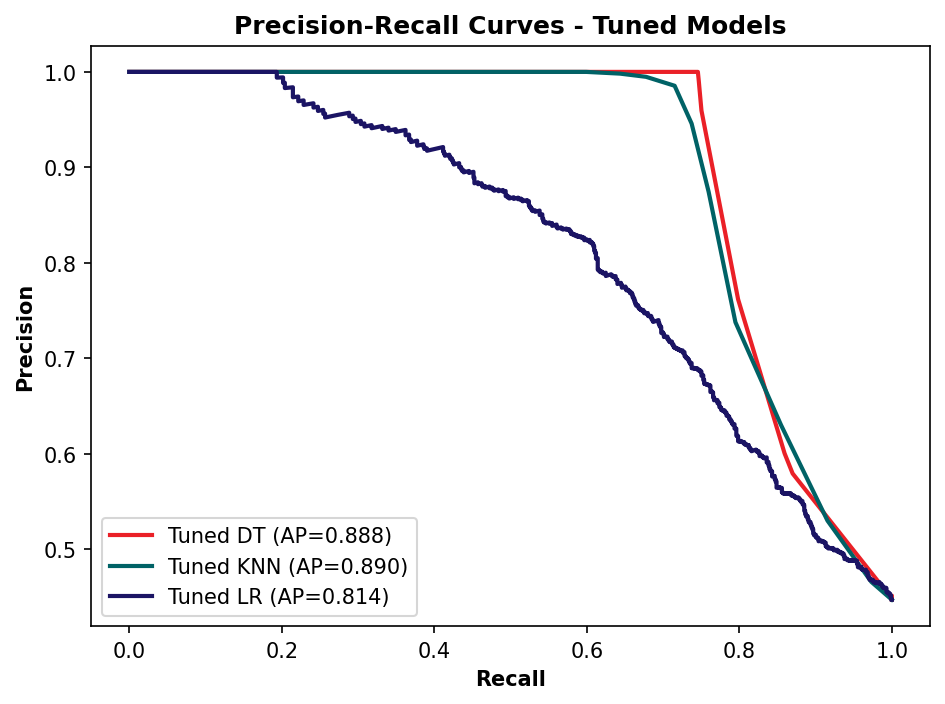

In [16]:
# Precision-recall too - catching attacks (recall) matters most here.
fig, ax = plt.subplots()
for name, model in {
    "Tuned DT": tuned_dt,
    "Tuned KNN": tuned_knn,
    "Tuned LR": tuned_lr,
}.items():
    # Same positive-column trick as the ROC cell.
    positive_col = int(np.flatnonzero(model.classes_ == 1)[0])
    proba = model.predict_proba(X_test)[:, positive_col]
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(
        recall, precision, lw=2, color=roc_colors[name], label=f"{name} (AP={ap:.3f})"
    )
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves - Tuned Models")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [17]:
# 12. All results side by side, plus a quick CV stability check.
results_table = pd.DataFrame(results).T
print("\n" + results_table.round(4).to_string())

# Double-check the LR score isn't a fluke: repeat CV with 5 and 10 folds.
logistic = LogisticRegression(max_iter=1000, random_state=SEED)
cv5 = cross_val_score(logistic, X_train, y_train, cv=5, scoring="accuracy")
cv10 = cross_val_score(logistic, X_train, y_train, cv=10, scoring="accuracy")
print(
    f"\nLR stability (fresh, default C):\n5-fold CV = {cv5.mean():.4f} +/- {cv5.std():.4f}"
)
print(f"10-fold CV = {cv10.mean():.4f} +/- {cv10.std():.4f}")


           Accuracy  Precision  Recall  F1-Score
DT           0.8040     0.8042  0.8040    0.8041
KNN          0.8475     0.8570  0.8475    0.8446
LR           0.7526     0.7522  0.7526    0.7510
Tuned DT     0.8863     0.9057  0.8863    0.8833
Tuned KNN    0.8679     0.8893  0.8679    0.8640
Tuned LR     0.7526     0.7522  0.7526    0.7510

LR stability (fresh, default C):
5-fold CV = 0.7614 +/- 0.0122
10-fold CV = 0.7613 +/- 0.0145


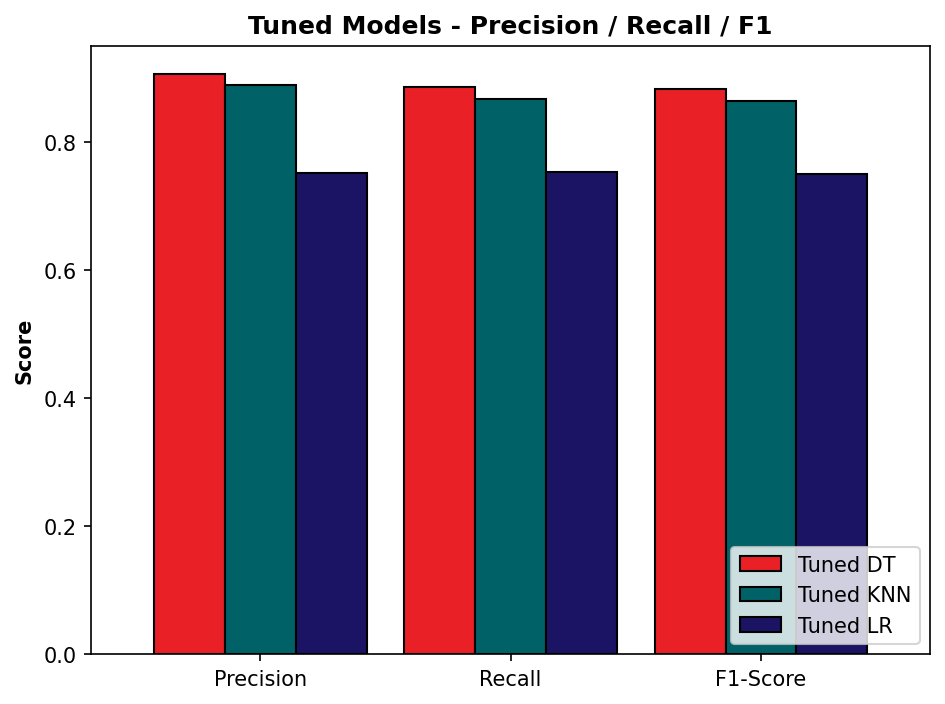

In [18]:
# P/R/F1 side by side for the 3 tuned models (using the shared bar helper).
tuned_metric_bars = pd.DataFrame(
    {
        name: {m: results[name][m] for m in ("Precision", "Recall", "F1-Score")}
        for name in ("Tuned DT", "Tuned KNN", "Tuned LR")
    }
)
plot_metric_bars(tuned_metric_bars, title="Tuned Models - Precision / Recall / F1")


            Train    Test     Gap
Tuned DT   0.8974  0.8863  0.0111
Tuned KNN  0.8811  0.8679  0.0132
Tuned LR   0.7630  0.7526  0.0104


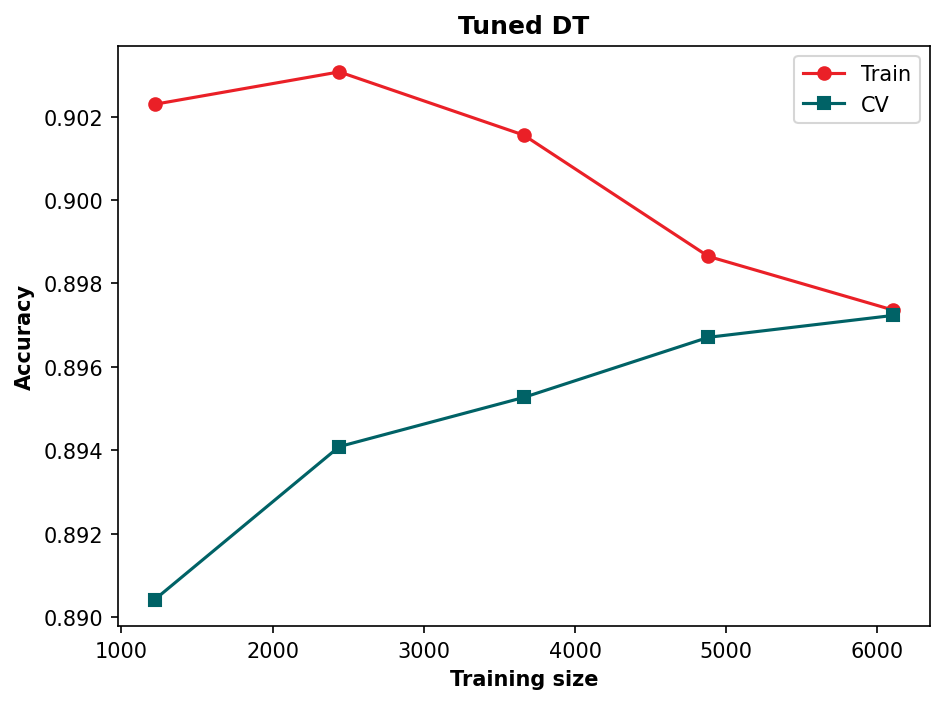

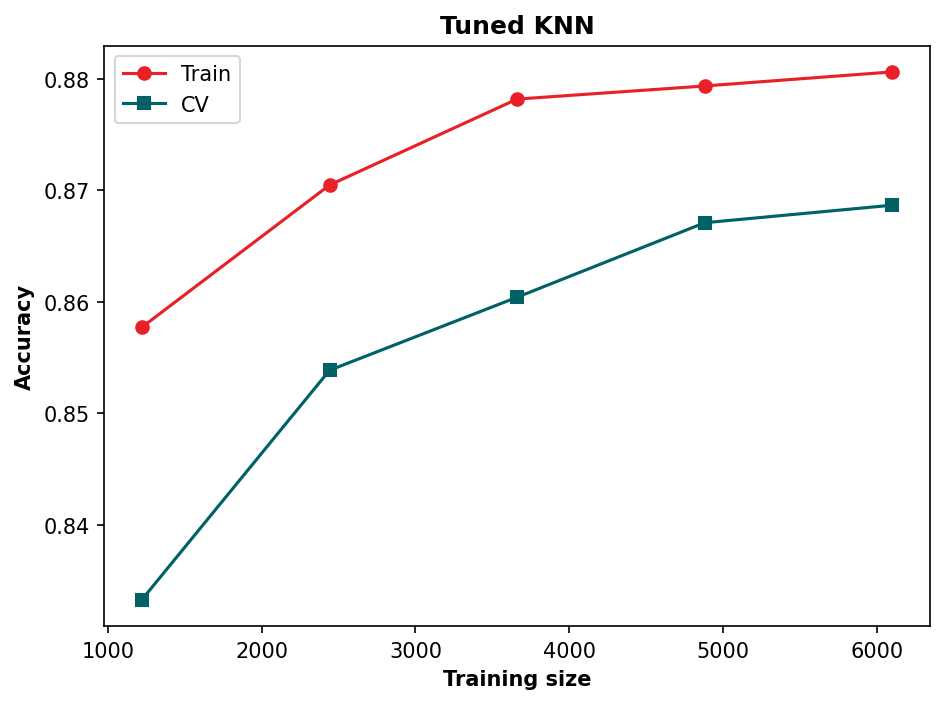

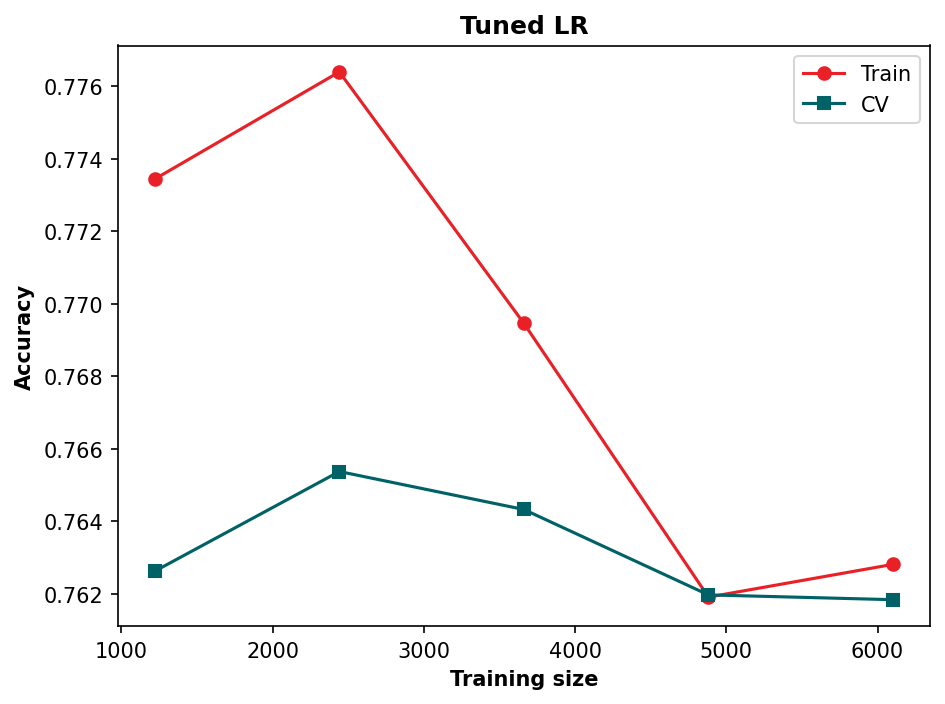

In [19]:
# 13. Over/underfitting check - compare train vs test, then look at learning curves.
tuned_models = {"Tuned DT": tuned_dt, "Tuned KNN": tuned_knn, "Tuned LR": tuned_lr}
fit_check = {}
for name, model in tuned_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    fit_check[name] = {
        "Train": train_acc,
        "Test": test_acc,
        "Gap": train_acc - test_acc,
    }
print("\n" + pd.DataFrame(fit_check).T.round(4).to_string())

for name, model in tuned_models.items():
    train_sizes, train_scores, cv_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1,
        random_state=SEED,
    )
    fig, ax = plt.subplots()
    ax.plot(
        train_sizes, train_scores.mean(axis=1), "o-", color=PALETTE[0], label="Train"
    )
    ax.plot(train_sizes, cv_scores.mean(axis=1), "s-", color=PALETTE[1], label="CV")
    ax.set_title(name)
    ax.set_xlabel("Training size")
    ax.set_ylabel("Accuracy")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

## Summary

- **Data & prep:** 9,537 sessions. Split first (80/20), then fit everything on train only (mode-fill, KNN imputation, scaling, RFE) so the test set never touches the learned steps. ~20% of `encryption_used` was blank and got KNN-imputed; RFE kept the top 8 features.
- **Baselines (accuracy):** DT 80.40% · KNN 84.75% · LR 75.26%.
- **Tuned (GridSearchCV):** **Decision Tree 88.63%** is the best (CV 89.72%), ahead of KNN 86.79% (k=13, manhattan, uniform) and LR 75.26% (C=10 - tuning didn't help it here).
- **ROC-AUC:** DT 0.871 ≈ KNN 0.870 > LR 0.806.
- **Bottom line:** the Decision Tree is the pick at ~88.6%; 90% wasn't reachable within the three-algorithm limit.
